# Preliminary Analysis - Hybrid Quantum-Classical Comparison
**Controlled ablation study isolating the quantum circuit contribution in a hybrid model.**

## 1. Environment Setup

Install all required packages. The analysis in Sections 5-7 runs entirely on CPU;
GPU is only required for training (Section 4). If the environment has already been
configured for the companion QCNN Benchmark notebook, the cell below is a no-op.

In [1]:
# Install all required packages (re-run if any import fails).
%pip install -q pennylane==0.45.0 pennylane-lightning==0.45.0 \
              torch torchvision \
              numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys, json, glob, warnings, math as _math, random, csv, time
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.datasets as _tvds
import torchvision.transforms as _tvtf
from torch.utils.data import (DataLoader as _DL, Dataset as _DS,
                              Subset as _Sub, TensorDataset as _TDS)

# Quantum computing
import pennylane as qml

warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

ROOT    = Path.cwd()
# Fallback: look for results in canonical locations
_result_candidates = [
    ROOT / "results_ablation",
    ROOT / "suitev3" / "results_s44",
    ROOT / "suitev3" / "results",
]
RESULTS = next((p for p in _result_candidates
                if p.exists() and any(p.rglob("test.json"))),
               ROOT / "results_ablation")

CLASS_NAMES = ["T-shirt", "Trouser", "Sneaker", "Bag"]
ARMS = ["trained", "frozen", "mlp8", "randfeat", "logistic"]
ARM_COLORS = {"trained":"#2196F3","frozen":"#03A9F4",
              "mlp8":"#FF9800","randfeat":"#FF5722","logistic":"#9E9E9E"}
ARM_LABELS = {"trained":"Quantum trained (Q1)","frozen":"Quantum frozen (Q2)",
              "logistic":"Logistic (C0)","mlp8":"MLP-8 (C1)","randfeat":"RandFeat (C2)"}

print(f"Results directory : {RESULTS}")
if RESULTS.exists():
    completed = list(RESULTS.rglob("test.json"))
    print(f"Completed runs    : {len(completed)}")
else:
    print("Results directory not found. Expected results_ablation/ at repository root.")

Results directory : c:\Users\ferdi\Documents\Github\SEAI_project_BRUTTO\results_ablation
Completed runs    : 15


## 2. Ablation Design

Five arms share the same 8-feature classical head; only the feature extractor (256 → 8) varies:

```
                  TRAINABLE          FIXED (random)
              +-----------------+---------------------+
  QUANTUM     |    trained      |       frozen        |
              +-----------------+---------------------+
  CLASSICAL   |     mlp8        |      randfeat       |
              +-----------------+---------------------+
              + logistic  (trivial linear reference)
```

Same seed → same data split across all arms. Paired comparisons:

| Comparison | What it measures |
|------------|-----------------|
| `trained − mlp8` | Quantum vs. classical trainable extractor |
| `frozen − randfeat` | Quantum vs. classical random features |
| `trained − frozen` | Value of *learning* the circuit |
| `trained − logistic` | Hybrid model vs. trivial linear classifier |

## 3. Model Architecture

### 3.1 HybridFlatQCNN (quantum arms)

```
x ∈ ℝ^256
  → AmplitudeEmbedding(x, wires=0..7)      [fixed state-preparation circuit]
  → hur8 conv on all 8 wires (θ ∈ ℝ^10)   [learned or frozen]
  → ⟨Z⟩_0 … ⟨Z⟩_7                         [8 features in [−1, 1]]
  → LayerNorm(8) + Linear(8, 4)            [52 trainable head parameters]
  → logits ∈ ℝ^4
```

### 3.2 Classical Baselines

| Arm | Architecture | Trainable params |
|-----|-------------|:----------------:|
| `mlp8` | `Linear(256,8) → tanh → LayerNorm(8) → Linear(8,4)` | ~2 108 |
| `randfeat` | Fixed cos-random projection → head | 52 (head only) |
| `logistic` | `Linear(256, 4)` | 1 028 |

`randfeat` is iso-parameter with `frozen` (52 trainable parameters each). The frozen circuit **precomputes features once** per dataset, training only the head on cached tensors (~15× speedup).

In [3]:
import pennylane as qml

# -- Ansatz circuits (inlined) ------------------------------------------------

def hur6(theta, wires):
    """SO(4) circuit, 6 parameters."""
    a, b = wires
    qml.RY(theta[0], wires=a); qml.RY(theta[1], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[2], wires=a); qml.RY(theta[3], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[4], wires=a); qml.RY(theta[5], wires=b)

def hur8(theta, wires):
    """Hur 2022 baseline circuit, 10 parameters."""
    a, b = wires
    qml.RX(theta[0], wires=a); qml.RX(theta[1], wires=b)
    qml.RZ(theta[2], wires=a); qml.RZ(theta[3], wires=b)
    qml.RX(theta[4], wires=a); qml.RX(theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RX(theta[6], wires=a); qml.RX(theta[7], wires=b)
    qml.RZ(theta[8], wires=a); qml.RZ(theta[9], wires=b)

def hur9(theta, wires):
    """SU(4) / KAK circuit, 15 parameters."""
    a, b = wires
    qml.U3(theta[0], theta[1], theta[2], wires=a)
    qml.U3(theta[3], theta[4], theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[6], wires=a); qml.RZ(theta[7], wires=b)
    qml.CNOT(wires=[b, a]); qml.RY(theta[8], wires=a)
    qml.CNOT(wires=[a, b])
    qml.U3(theta[9],  theta[10], theta[11], wires=a)
    qml.U3(theta[12], theta[13], theta[14], wires=b)

def custom_ansatz(theta, wires):
    """Cartan-inspired circuit, 11 parameters."""
    a, b = wires
    qml.RZ(theta[0], wires=a); qml.RY(theta[1], wires=a)
    qml.RZ(theta[2], wires=b); qml.RY(theta[3], wires=b)
    qml.IsingXX(theta[4], wires=[a, b])
    qml.IsingYY(theta[5], wires=[a, b])
    qml.IsingZZ(theta[6], wires=[a, b])
    qml.RY(theta[7], wires=a); qml.RZ(theta[8], wires=a)
    qml.RY(theta[9], wires=b); qml.RZ(theta[10], wires=b)

def conv_layer(conv_fn, theta, active_wires):
    """Translationally invariant conv: even + shifted pairs, shared params."""
    n = len(active_wires)
    even    = [(active_wires[i], active_wires[i+1]) for i in range(0, n-1, 2)]
    shifted = [(active_wires[i], active_wires[i+1]) for i in range(1, n-1, 2)]
    for pair in even + shifted:
        conv_fn(theta, pair)

print("Ansatz circuits defined.")

Ansatz circuits defined.


In [4]:
# -- Visualise the HybridFlatQCNN quantum backbone ----------------------------
import torch
N = 8
dev = qml.device("default.qubit", wires=N)

@qml.qnode(dev)
def hybrid_circuit(x, theta):
    qml.AmplitudeEmbedding(x, wires=range(N), normalize=True)
    conv_layer(hur8, theta, list(range(N)))
    return [qml.expval(qml.PauliZ(w)) for w in range(N)]

x_d = torch.rand(2**N)
x_d /= x_d.norm()
theta_d = torch.zeros(10)
print("HybridFlatQCNN backbone  (AmplitudeEmbedding + hur8 flat conv, 8 <Z> readouts):")
print(qml.draw(hybrid_circuit)(x_d.numpy(), theta_d.numpy()))

HybridFlatQCNN backbone  (AmplitudeEmbedding + hur8 flat conv, 8 <Z> readouts):
0: ─╭|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)───────────────────────────────── ···
1: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
2: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
3: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
4: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
5: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
6: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
7: ─╰|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)───────────────────────────────── ···

0: ··· ─────────────────────┤  <Z>
1: ··· ──RX(0.00)──RZ(0.00)─┤  <Z>
2: ··· ──RX(0.00)──RZ(0.00)─┤  <Z>
3: ··· ──RX(0.00)──RZ(

### 3.3 Training Library

All code needed to reproduce the 15 ablation runs from scratch.
Run cells 3c-1 through 3c-4 once before using the CLI in Section 4.
If only using the pre-computed results, skip directly to Section 5.

In [5]:
# 3c-1 -- Imports and hyperparameters --------------------------------------
import math as _math, random, csv, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as _tvds
import torchvision.transforms as _tvtf
from torch.utils.data import (DataLoader as _DL, Dataset as _DS,
                              Subset as _Sub, TensorDataset as _TDS)

IMG_SIZE        = 16
N_CLASSES       = 4
CLASS_MAP       = {0: 0, 1: 1, 7: 2, 8: 3}
TRAIN_PER_CLASS = 3000
VAL_PER_CLASS   = 500
TEST_PER_CLASS  = 500
BATCH_SIZE      = 24
EPOCHS_DEFAULT  = 20
ABL_LR          = 1e-3
ABL_WD          = 0.0
LABEL_SMOOTHING          = 0.1
EARLY_STOP_PATIENCE      = 10
EARLY_STOP_MIN_REL       = 1e-2   # relative improvement on val_loss
ABL_N_QUBITS             = 8
ABL_N_READOUT            = 8
ABL_N_CONV_PARAMS        = 10
ABL_TRAINED_INIT_SCALE   = 0.01
ABL_FROZEN_INIT_HIGH     = 2.0 * _math.pi
ABL_PIXEL_DIM            = 256
ABL_RANDFEAT_DIM         = 8


def set_seed_abl(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


print('3c-1: config ready.')

3c-1: config ready.


In [6]:
# 3c-2 -- Data loading (4-class Fashion-MNIST, 16x16) ----------------------
_abl_tf = _tvtf.Compose([_tvtf.Resize((IMG_SIZE, IMG_SIZE)), _tvtf.ToTensor()])


def _abl_qm8(x):
    img = x.squeeze(0)
    return torch.stack([img[r*8:(r+1)*8, c*4:(c+1)*4].mean()
                        for r in range(2) for c in range(4)])


def _abl_ga4(x):
    img = x.squeeze(0)
    gx  = img[:, 1:] - img[:, :-1]
    gy  = img[1:, :] - img[:-1, :]
    hv  = img.var(dim=1, unbiased=False).mean()
    vv  = img.var(dim=0, unbiased=False).mean()
    return torch.stack([
        img.mean() - 0.5, img.var(unbiased=False),
        (gx.pow(2).mean() + gy.pow(2).mean()) / 2,
        (hv - vv) / (hv + vv + 1e-8),
    ])


class _AblDS(_DS):
    def __init__(self, subset, class_map):
        self.subset = subset; self.class_map = class_map

    def __len__(self): return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return x.reshape(-1), _abl_qm8(x), _abl_ga4(x), self.class_map[int(y)]


def _abl_balanced_idx(ds, class_map, n, offset=0, seed=42):
    buckets = {c: [] for c in class_map}
    for i in range(len(ds)):
        y = int(ds[i][1])
        if y in buckets: buckets[y].append(i)
    sel = []
    rng = np.random.default_rng(seed)
    for c in class_map:
        arr = np.array(buckets[c]); rng.shuffle(arr)
        if offset + n > len(arr):
            raise ValueError(f'Not enough samples for class {c}')
        sel.extend(arr[offset:offset + n].tolist())
    rng.shuffle(sel)
    return sel


def load_data_abl(seed=42, batch_size=BATCH_SIZE, train_per_class=TRAIN_PER_CLASS):
    cache = str(ROOT / '.cache' / 'fmnist')
    trn = _tvds.FashionMNIST(root=cache, train=True,  download=True, transform=_abl_tf)
    tst = _tvds.FashionMNIST(root=cache, train=False, download=True, transform=_abl_tf)
    ti = _abl_balanced_idx(trn, CLASS_MAP, train_per_class, 0, seed)
    vi = _abl_balanced_idx(trn, CLASS_MAP, VAL_PER_CLASS,   train_per_class, seed)
    ei = _abl_balanced_idx(tst, CLASS_MAP, TEST_PER_CLASS,  0, seed)
    trl = _DL(_AblDS(_Sub(trn, ti), CLASS_MAP), batch_size=batch_size, shuffle=True)
    vll = _DL(_AblDS(_Sub(trn, vi), CLASS_MAP), batch_size=batch_size, shuffle=False)
    tel = _DL(_AblDS(_Sub(tst, ei), CLASS_MAP), batch_size=batch_size, shuffle=False)
    return trl, vll, tel


print('3c-2: data loading ready.')

3c-2: data loading ready.


In [7]:
# 3c-3 -- HybridFlatQCNN and classical baselines ---------------------------


def _conv_flat(conv_fn, theta, wires):
    n = len(wires)
    even    = [(wires[i], wires[i+1]) for i in range(0, n-1, 2)]
    shifted = [(wires[i], wires[i+1]) for i in range(1, n-1, 2)]
    for pair in even + shifted: conv_fn(theta, pair)


class HybridFlatQCNN(nn.Module):
    def __init__(self, freeze_quantum=False):
        super().__init__()
        n = ABL_N_CONV_PARAMS
        theta = (torch.empty(n).uniform_(0.0, ABL_FROZEN_INIT_HIGH)
                 if freeze_quantum else ABL_TRAINED_INIT_SCALE * torch.randn(n))
        self.theta_conv = nn.Parameter(theta, requires_grad=not freeze_quantum)
        self.head = nn.Sequential(
            nn.LayerNorm(ABL_N_READOUT),
            nn.Linear(ABL_N_READOUT, N_CLASSES),
        )
        self.dev   = qml.device('default.qubit', wires=ABL_N_QUBITS)
        self.qnode = self._build_qnode()

    def _build_qnode(self):
        @qml.qnode(self.dev, interface='torch', diff_method='backprop')
        def _q(x_flat, theta_conv):
            qml.AmplitudeEmbedding(features=x_flat, wires=range(ABL_N_QUBITS), normalize=True)
            _conv_flat(hur8, theta_conv, list(range(ABL_N_QUBITS)))
            return [qml.expval(qml.PauliZ(w)) for w in range(ABL_N_QUBITS)]
        return _q

    def features(self, x_flat):
        out = self.qnode(x_flat, self.theta_conv)
        if isinstance(out, (list, tuple)):
            feats = torch.stack(out, dim=-1)
        else:
            feats = out
            if feats.dim() == 2 and feats.shape[0] == ABL_N_READOUT:
                feats = feats.transpose(0, 1)
        return feats.float()

    def forward(self, x_flat, *args, **kwargs):
        return self.head(self.features(x_flat))

    def n_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class LogisticBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(ABL_PIXEL_DIM, N_CLASSES)

    def forward(self, x_flat, *args, **kwargs):
        return self.fc(x_flat.float())

    def n_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class RandomFeatureBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        import math as _m
        W = torch.randn(ABL_PIXEL_DIM, ABL_RANDFEAT_DIM) / _m.sqrt(ABL_PIXEL_DIM)
        b = torch.empty(ABL_RANDFEAT_DIM).uniform_(0.0, 2.0 * _m.pi)
        self.register_buffer('W', W)
        self.register_buffer('b', b)
        self.head = nn.Sequential(
            nn.LayerNorm(ABL_RANDFEAT_DIM), nn.Linear(ABL_RANDFEAT_DIM, N_CLASSES))

    def forward(self, x_flat, *args, **kwargs):
        return self.head(torch.cos(x_flat.float() @ self.W + self.b))

    def n_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class MLP8Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.extractor = nn.Linear(ABL_PIXEL_DIM, ABL_RANDFEAT_DIM)
        self.head = nn.Sequential(
            nn.LayerNorm(ABL_RANDFEAT_DIM), nn.Linear(ABL_RANDFEAT_DIM, N_CLASSES))

    def forward(self, x_flat, *args, **kwargs):
        return self.head(torch.tanh(self.extractor(x_flat.float())))

    def n_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model_abl(arm):
    if arm == 'logistic': return LogisticBaseline()
    if arm == 'randfeat': return RandomFeatureBaseline()
    if arm == 'mlp8':     return MLP8Baseline()
    if arm in ('trained', 'frozen'):
        return HybridFlatQCNN(freeze_quantum=(arm == 'frozen'))
    raise ValueError(f'Unknown arm: {arm!r}')


print('3c-3: models ready.')

3c-3: models ready.


In [8]:
# 3c-4 -- Training loop and ablation suite runner --------------------------


def _abl_epoch(model, loader, device, opt=None):
    model.train() if opt else model.eval()
    tl = ta = tn = 0.0
    for xf, _qm, _ga, y in loader:
        xf, y = xf.to(device), y.to(device)
        if opt: opt.zero_grad()
        logits = model(xf)
        loss   = F.cross_entropy(logits, y,
                     label_smoothing=LABEL_SMOOTHING if opt else 0.0)
        if opt:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad), 1.0)
            opt.step()
        bs = xf.shape[0]
        tl += loss.item()*bs; ta += (logits.argmax(1)==y).float().mean().item()*bs; tn += bs
    return tl/tn, ta/tn


def _head_epoch(head, loader, device, opt=None):
    head.train() if opt else head.eval()
    tl = ta = tn = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if opt: opt.zero_grad()
        logits = head(xb)
        loss   = F.cross_entropy(logits, yb,
                     label_smoothing=LABEL_SMOOTHING if opt else 0.0)
        if opt:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()
        bs = xb.shape[0]
        tl += loss.item()*bs; ta += (logits.argmax(1)==yb).float().sum().item(); tn += bs
    return tl/tn, ta/tn


def _abl_confusion(model_or_head, loader, device, is_head=False):
    cm = torch.zeros(N_CLASSES, N_CLASSES, dtype=torch.int64)
    model_or_head.eval()
    with torch.no_grad():
        for batch in loader:
            if is_head:
                xb, yb = batch
                preds = model_or_head(xb.to(device)).argmax(1).cpu()
            else:
                xf, _qm, _ga, yb = batch
                preds = model_or_head(xf.to(device)).argmax(1).cpu()
            for t, p in zip(yb, preds): cm[int(t), int(p)] += 1
    return cm


def _cache_features(model, loader, device):
    model.eval()
    Xs, ys = [], []
    with torch.no_grad():
        for xf, _qm, _ga, y in loader:
            Xs.append(model.features(xf.to(device)).cpu())
            ys.append(y)
    return torch.cat(Xs), torch.cat(ys)


def _train_frozen(seed, run_dir, epochs=EPOCHS_DEFAULT,
                  train_per_class=TRAIN_PER_CLASS, log_fn=print):
    import json as _json
    set_seed_abl(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = HybridFlatQCNN(freeze_quantum=True).to(device)
    n_p    = model.n_trainable_params()
    trl, vll, tel = load_data_abl(seed=seed, train_per_class=train_per_class)

    t0 = time.time()
    Xtr, ytr = _cache_features(model, trl, device)
    Xva, yva = _cache_features(model, vll, device)
    Xte, yte = _cache_features(model, tel, device)
    log_fn(f'  features cached in {time.time()-t0:.1f}s')

    bs = BATCH_SIZE
    tr_dl = _DL(_TDS(Xtr, ytr), batch_size=bs, shuffle=True)
    va_dl = _DL(_TDS(Xva, yva), batch_size=bs, shuffle=False)
    te_dl = _DL(_TDS(Xte, yte), batch_size=bs, shuffle=False)

    head = model.head
    opt  = torch.optim.AdamW(head.parameters(), lr=ABL_LR, weight_decay=ABL_WD)
    T0   = max(1, epochs // 3)
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=T0, T_mult=1, eta_min=1e-4)

    os.makedirs(run_dir, exist_ok=True)
    with open(os.path.join(run_dir, 'config.json'), 'w') as f:
        _json.dump({'arm': 'frozen', 'seed': seed, 'epochs': epochs,
                    'lr': ABL_LR, 'weight_decay': ABL_WD, 'batch_size': bs,
                    'label_smoothing': LABEL_SMOOTHING,
                    'train_per_class': train_per_class,
                    'n_trainable_params': n_p, 'cached_features': True}, f, indent=2)

    mf = open(os.path.join(run_dir, 'metrics.csv'), 'w', newline='')
    mw = csv.writer(mf)
    mw.writerow(['epoch','train_loss','train_acc','val_loss','val_acc','time_sec'])
    mf.flush()

    bvl = float('inf'); bep = -1; bhs = None
    vab = -1.0; patience = 0; va_f = 0.0
    try:
        for ep in range(1, epochs + 1):
            t0 = time.time()
            tl, ta = _head_epoch(head, tr_dl, device, opt)
            vl, va = _head_epoch(head, va_dl, device)
            sch.step(); dt = time.time() - t0
            mw.writerow([ep, f'{tl:.6f}', f'{ta:.6f}',
                         f'{vl:.6f}', f'{va:.6f}', f'{dt:.2f}'])
            mf.flush(); os.fsync(mf.fileno())
            min_impr = abs(bvl) * EARLY_STOP_MIN_REL
            if not np.isfinite(bvl) or vl < bvl - min_impr:
                bvl = vl; bep = ep; vab = va; patience = 0
                bhs = {k: v.detach().cpu().clone()
                       for k, v in head.state_dict().items()}
            else:
                patience += 1
            va_f = va
            log_fn(f'  ep {ep:02d} | train {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | {dt:.1f}s')
            if patience >= EARLY_STOP_PATIENCE:
                log_fn(f'  Early stop at epoch {ep}'); break
    finally:
        mf.close()

    if bhs is not None: head.load_state_dict(bhs)
    torch.save({'model_state': model.state_dict()},
               os.path.join(run_dir, 'best_state.pt'))
    tl_t, ta_t = _head_epoch(head, te_dl, device)
    cm = _abl_confusion(head, te_dl, device, is_head=True)
    result = {'arm': 'frozen', 'seed': seed, 'n_params': n_p,
              'n_epochs_trained': bep if bep > 0 else epochs,
              'best_epoch': bep if bep > 0 else epochs,
              'best_val_loss': bvl, 'val_acc_best': vab,
              'test_loss': tl_t, 'test_acc': ta_t, 'confusion_matrix': cm.tolist()}
    with open(os.path.join(run_dir, 'test.json'), 'w') as f:
        _json.dump(result, f, indent=2)
    return result


def train_one_run_abl(arm, seed, run_dir, epochs=EPOCHS_DEFAULT,
                       train_per_class=TRAIN_PER_CLASS, log_fn=print):
    if arm == 'frozen':
        return _train_frozen(seed, run_dir, epochs, train_per_class, log_fn)

    import json as _json
    set_seed_abl(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = build_model_abl(arm).to(device)
    n_p    = model.n_trainable_params()
    trl, vll, tel = load_data_abl(seed=seed, train_per_class=train_per_class)

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=ABL_LR, weight_decay=ABL_WD)
    T0  = max(1, epochs // 3)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=T0, T_mult=1, eta_min=1e-4)

    os.makedirs(run_dir, exist_ok=True)
    with open(os.path.join(run_dir, 'config.json'), 'w') as f:
        _json.dump({'arm': arm, 'seed': seed, 'epochs': epochs,
                    'lr': ABL_LR, 'weight_decay': ABL_WD, 'batch_size': BATCH_SIZE,
                    'label_smoothing': LABEL_SMOOTHING,
                    'train_per_class': train_per_class, 'n_trainable_params': n_p}, f, indent=2)

    mf = open(os.path.join(run_dir, 'metrics.csv'), 'w', newline='')
    mw = csv.writer(mf)
    mw.writerow(['epoch','train_loss','train_acc','val_loss','val_acc','time_sec'])
    mf.flush()

    bvl = float('inf'); bep = -1; bs_ = None
    vab = -1.0; patience = 0; va_f = 0.0
    try:
        for ep in range(1, epochs + 1):
            t0 = time.time()
            tl, ta = _abl_epoch(model, trl, device, opt)
            vl, va = _abl_epoch(model, vll, device)
            sch.step(); dt = time.time() - t0
            mw.writerow([ep, f'{tl:.6f}', f'{ta:.6f}',
                         f'{vl:.6f}', f'{va:.6f}', f'{dt:.2f}'])
            mf.flush(); os.fsync(mf.fileno())
            min_impr = abs(bvl) * EARLY_STOP_MIN_REL
            if not np.isfinite(bvl) or vl < bvl - min_impr:
                bvl = vl; bep = ep; vab = va; patience = 0
                bs_ = {k: v.detach().cpu().clone()
                       for k, v in model.state_dict().items()}
            else:
                patience += 1
            va_f = va
            log_fn(f'  ep {ep:02d} | train {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | {dt:.1f}s')
            if patience >= EARLY_STOP_PATIENCE:
                log_fn(f'  Early stop at epoch {ep}'); break
    finally:
        mf.close()

    if bs_ is not None:
        torch.save({'model_state': bs_}, os.path.join(run_dir, 'best_state.pt'))
        model.load_state_dict(bs_)

    tl_t, ta_t = _abl_epoch(model, tel, device)
    cm = _abl_confusion(model, tel, device, is_head=False)
    result = {'arm': arm, 'seed': seed, 'n_params': n_p,
              'n_epochs_trained': bep if bep > 0 else epochs,
              'best_epoch': bep if bep > 0 else epochs,
              'best_val_loss': bvl, 'val_acc_best': vab,
              'test_loss': tl_t, 'test_acc': ta_t, 'confusion_matrix': cm.tolist()}
    with open(os.path.join(run_dir, 'test.json'), 'w') as f:
        _json.dump(result, f, indent=2)
    return result


def run_ablation_suite(arms, seeds, epochs, train_per_class, results_dir):
    from pathlib import Path as _P
    rd = _P(results_dir); rd.mkdir(parents=True, exist_ok=True)
    total = len(arms) * len(seeds)
    done = 0; t0s = time.time()
    print('=' * 65)
    print(f'Ablation suite: {len(arms)} arms x {len(seeds)} seeds = {total} runs')
    print('=' * 65)
    for arm in arms:
        for seed in seeds:
            name = f'{arm}_seed{seed}'
            rdir = str(rd / name); done += 1
            if (rd / name / 'test.json').exists():
                print(f'[{done}/{total}] SKIP {name}'); continue
            print(f'[{done}/{total}] START {name}')
            t0 = time.time()
            r  = train_one_run_abl(arm, seed, rdir, epochs, train_per_class)
            print(f'  DONE {time.time()-t0:.1f}s | test_acc={r["test_acc"]:.4f}')
            if done < total:
                avg = (time.time() - t0s) / done
                print(f'  ETA ~{(total-done)*avg/60:.1f} min')
    print('=' * 65)
    print(f'FINISHED {total} runs in {(time.time()-t0s)/60:.1f} min')


print('3c-4: training library ready.')

3c-4: training library ready.


## 4. Running the Experiments

Run the cell below to reproduce any subset of the 15 ablation runs.
Completed runs (with a `test.json` present) are automatically skipped.

**Smoke test**: set `CLI_TRAIN_N = 50` and `CLI_EPOCHS = 1` to verify
the full pipeline in ~2 minutes before launching the full suite.

In [ ]:
# ============================================================
# Training CLI  --  edit variables below, then Run Cell
# ============================================================
ARMS_TO_RUN    = ['trained', 'frozen', 'mlp8', 'randfeat', 'logistic']
SEEDS_TO_RUN   = [42, 43, 44]
CLI_EPOCHS     = 20
CLI_TRAIN_N    = 3000   # samples per class  (set 50 for a smoke test)
CLI_RESULTS_DIR = RESULTS  # ROOT / 'results_ablation' (defined in cell 3)

run_ablation_suite(ARMS_TO_RUN, SEEDS_TO_RUN, CLI_EPOCHS,
                   CLI_TRAIN_N, CLI_RESULTS_DIR)

## 5. Loading Results

Scans `results_ablation/` recursively for `test.json` files (one per arm × seed subdirectory) and assembles a single DataFrame.

In [9]:
df3_raw = None
df3     = None

def _load_results_ablation(results_dir):
    """Scan results_dir recursively for test.json files and build a DataFrame."""
    records = []
    if not results_dir.exists():
        return records
    for test_json in sorted(results_dir.rglob("test.json")):
        run_dir = test_json.parent
        try:
            with open(test_json, encoding="utf-8") as f:
                rec = json.load(f)
            cm = rec.get("confusion_matrix", [[0] * 4 for _ in range(4)])
            flat_cm = {f"cm_{i}{j}": cm[i][j] for i in range(4) for j in range(4)}
            records.append({
                "arm":             rec.get("arm"),
                "seed":            rec.get("seed"),
                "n_params":        rec.get("n_params"),
                "n_epochs_trained":rec.get("n_epochs_trained"),
                "best_epoch":      rec.get("best_epoch"),
                "best_val_loss":   rec.get("best_val_loss"),
                "val_acc_best":    rec.get("val_acc_best"),
                "test_loss":       rec.get("test_loss"),
                "test_acc":        rec.get("test_acc"),
                **flat_cm,
                "_run_dir":        str(run_dir),
            })
        except Exception as exc:
            print(f"WARNING: could not load {test_json}: {exc}")
    return records

records3 = _load_results_ablation(RESULTS)

if not records3:
    print("WARNING: No completed runs found.")
    print("   -> Expected results in results_ablation/ at the repository root.")
else:
    df3 = pd.DataFrame(records3)
    for c in ["test_acc", "val_acc_best", "test_loss", "best_val_loss",
              "n_params", "best_epoch", "n_epochs_trained"]:
        if c in df3.columns:
            df3[c] = pd.to_numeric(df3[c], errors="coerce")

    print(f"[OK]  {len(df3)} runs loaded  |  "
          f"arms: {sorted(df3['arm'].unique())}  |  "
          f"seeds: {sorted(df3['seed'].unique())}")
    display(df3[["arm", "seed", "n_params", "n_epochs_trained",
                 "test_acc", "val_acc_best", "best_epoch"]]
            .sort_values(["arm", "seed"]).to_string(index=False))

[OK]  15 runs loaded  |  arms: ['frozen', 'logistic', 'mlp8', 'randfeat', 'trained']  |  seeds: [np.int64(42), np.int64(43), np.int64(44)]


'     arm  seed  n_params  n_epochs_trained  test_acc  val_acc_best  best_epoch\n  frozen    42        52                19    0.8990        0.9070          19\n  frozen    43        52                13    0.9160        0.9170          13\n  frozen    44        52                16    0.8650        0.8640          16\nlogistic    42      1028                20    0.9790        0.9830          20\nlogistic    43      1028                16    0.9815        0.9795          16\nlogistic    44      1028                19    0.9775        0.9865          19\n    mlp8    42      2108                16    0.9830        0.9845          16\n    mlp8    43      2108                 5    0.9810        0.9830           5\n    mlp8    44      2108                13    0.9810        0.9875          13\nrandfeat    42        52                19    0.8065        0.8265          19\nrandfeat    43        52                20    0.8900        0.8990          20\nrandfeat    44        52               

In [10]:
curves3 = {}
if RESULTS.exists():
    for p in sorted(RESULTS.rglob("metrics.csv")):
        if ".ipynb_checkpoints" in str(p):
            continue
        run = p.parent.name          # e.g. "trained_seed42"
        parts = run.rsplit("_seed", 1)
        if len(parts) == 2:
            key = parts[0]           # e.g. "trained"
            try:
                c = pd.read_csv(p)
                for col in ["train_loss","train_acc","val_loss","val_acc"]:
                    if col in c.columns:
                        c[col] = pd.to_numeric(c[col], errors="coerce")
                curves3.setdefault(key, []).append(c)
            except Exception:
                pass
print(f"Curves loaded: {sum(len(v) for v in curves3.values())} runs, "
      f"arms: {sorted(curves3.keys())}")

Curves loaded: 15 runs, arms: ['frozen', 'logistic', 'mlp8', 'randfeat', 'trained']


## 6. Analysis

### 6.1 Arm Comparison

Test accuracy for each arm averaged over 3 seeds. Each arm is shown with its mean (horizontal bar), ±1 standard deviation (dashed vertical bar), and individual seed results (dots). Colour distinguishes quantum arms (blue) from classical arms (orange/red) and the trivial baseline (grey).

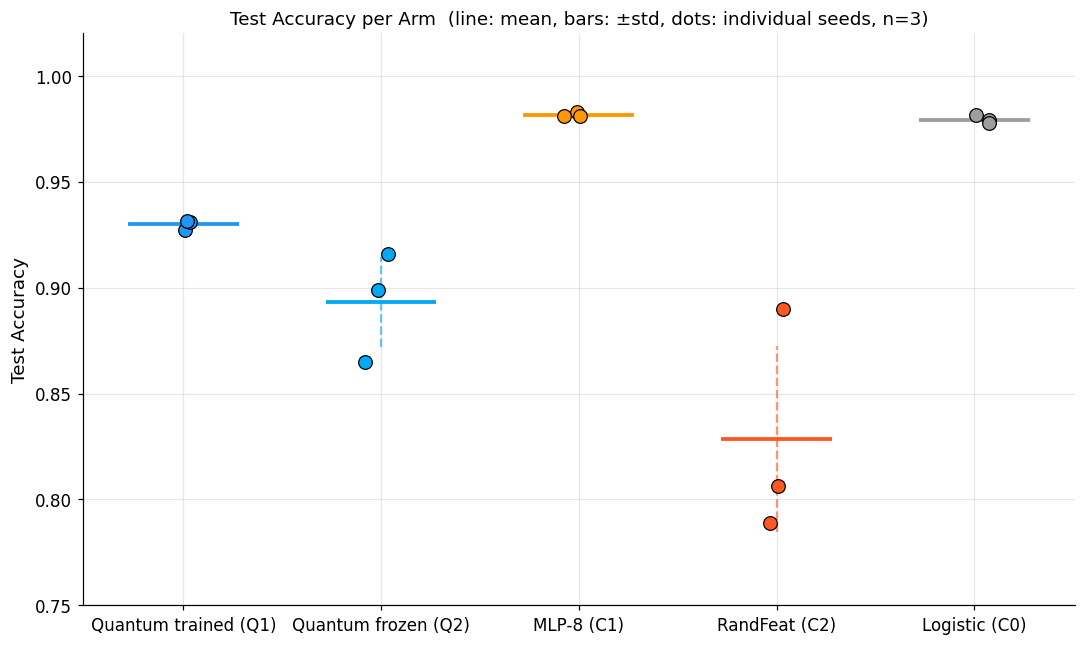

Arm comparison summary (mean ± std over 3 seeds):


'     arm  mean_acc  std_acc  n_seeds\n trained    0.9298   0.0025        3\n  frozen    0.8933   0.0260        3\n    mlp8    0.9817   0.0012        3\nrandfeat    0.8285   0.0540        3\nlogistic    0.9793   0.0020        3'

In [11]:
def _nd3(s): print(f"WARNING:  No data for {s} . Ensure results_ablation/ is populated, then re-run Section 5.")

if df3 is None:
    _nd3("6.1")
else:
    present_arms = [a for a in ARMS if a in df3["arm"].unique()]

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, arm in enumerate(present_arms):
        vals = df3[df3["arm"] == arm]["test_acc"].values
        color = ARM_COLORS.get(arm, "#9E9E9E")
        mean_v = vals.mean()
        std_v  = vals.std()
        # ±std error bars (dashed)
        ax.vlines(i, mean_v - std_v, mean_v + std_v,
                  colors=color, lw=1.5, linestyle="--", alpha=0.6, zorder=3)
        # mean line
        ax.hlines(mean_v, i - 0.28, i + 0.28, colors=color, lw=2.5, zorder=4)
        # individual seed points
        np.random.seed(i)
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, s=80, zorder=5, edgecolors="black", lw=0.8)

    ax.set_xticks(range(len(present_arms)))
    ax.set_xticklabels([ARM_LABELS.get(a, a) for a in present_arms], fontsize=11)
    ax.set_ylabel("Test Accuracy", fontsize=12)
    ax.set_ylim(0.75, 1.02)
    ax.set_title("Test Accuracy per Arm  (line: mean, bars: ±std, dots: individual seeds, n=3)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    # Numeric summary
    print("Arm comparison summary (mean ± std over 3 seeds):")
    grp_s = df3.groupby("arm")["test_acc"].agg(["mean", "std", "count"]).reset_index()
    grp_s["std"] = grp_s["std"].fillna(0)
    grp_s["_order"] = grp_s["arm"].map({a: i for i, a in enumerate(ARMS)}).fillna(99)
    grp_s = grp_s.sort_values("_order").drop(columns=["_order"]).reset_index(drop=True)
    display(grp_s.rename(columns={"mean": "mean_acc", "std": "std_acc",
                                   "count": "n_seeds"}).round(4).to_string(index=False))

### 6.2 Paired Delta Analysis

Within-seed accuracy deltas (same seed = same images). Eliminates data-sampling variance.
Positive Delta = first arm better; dots = per-seed deltas.

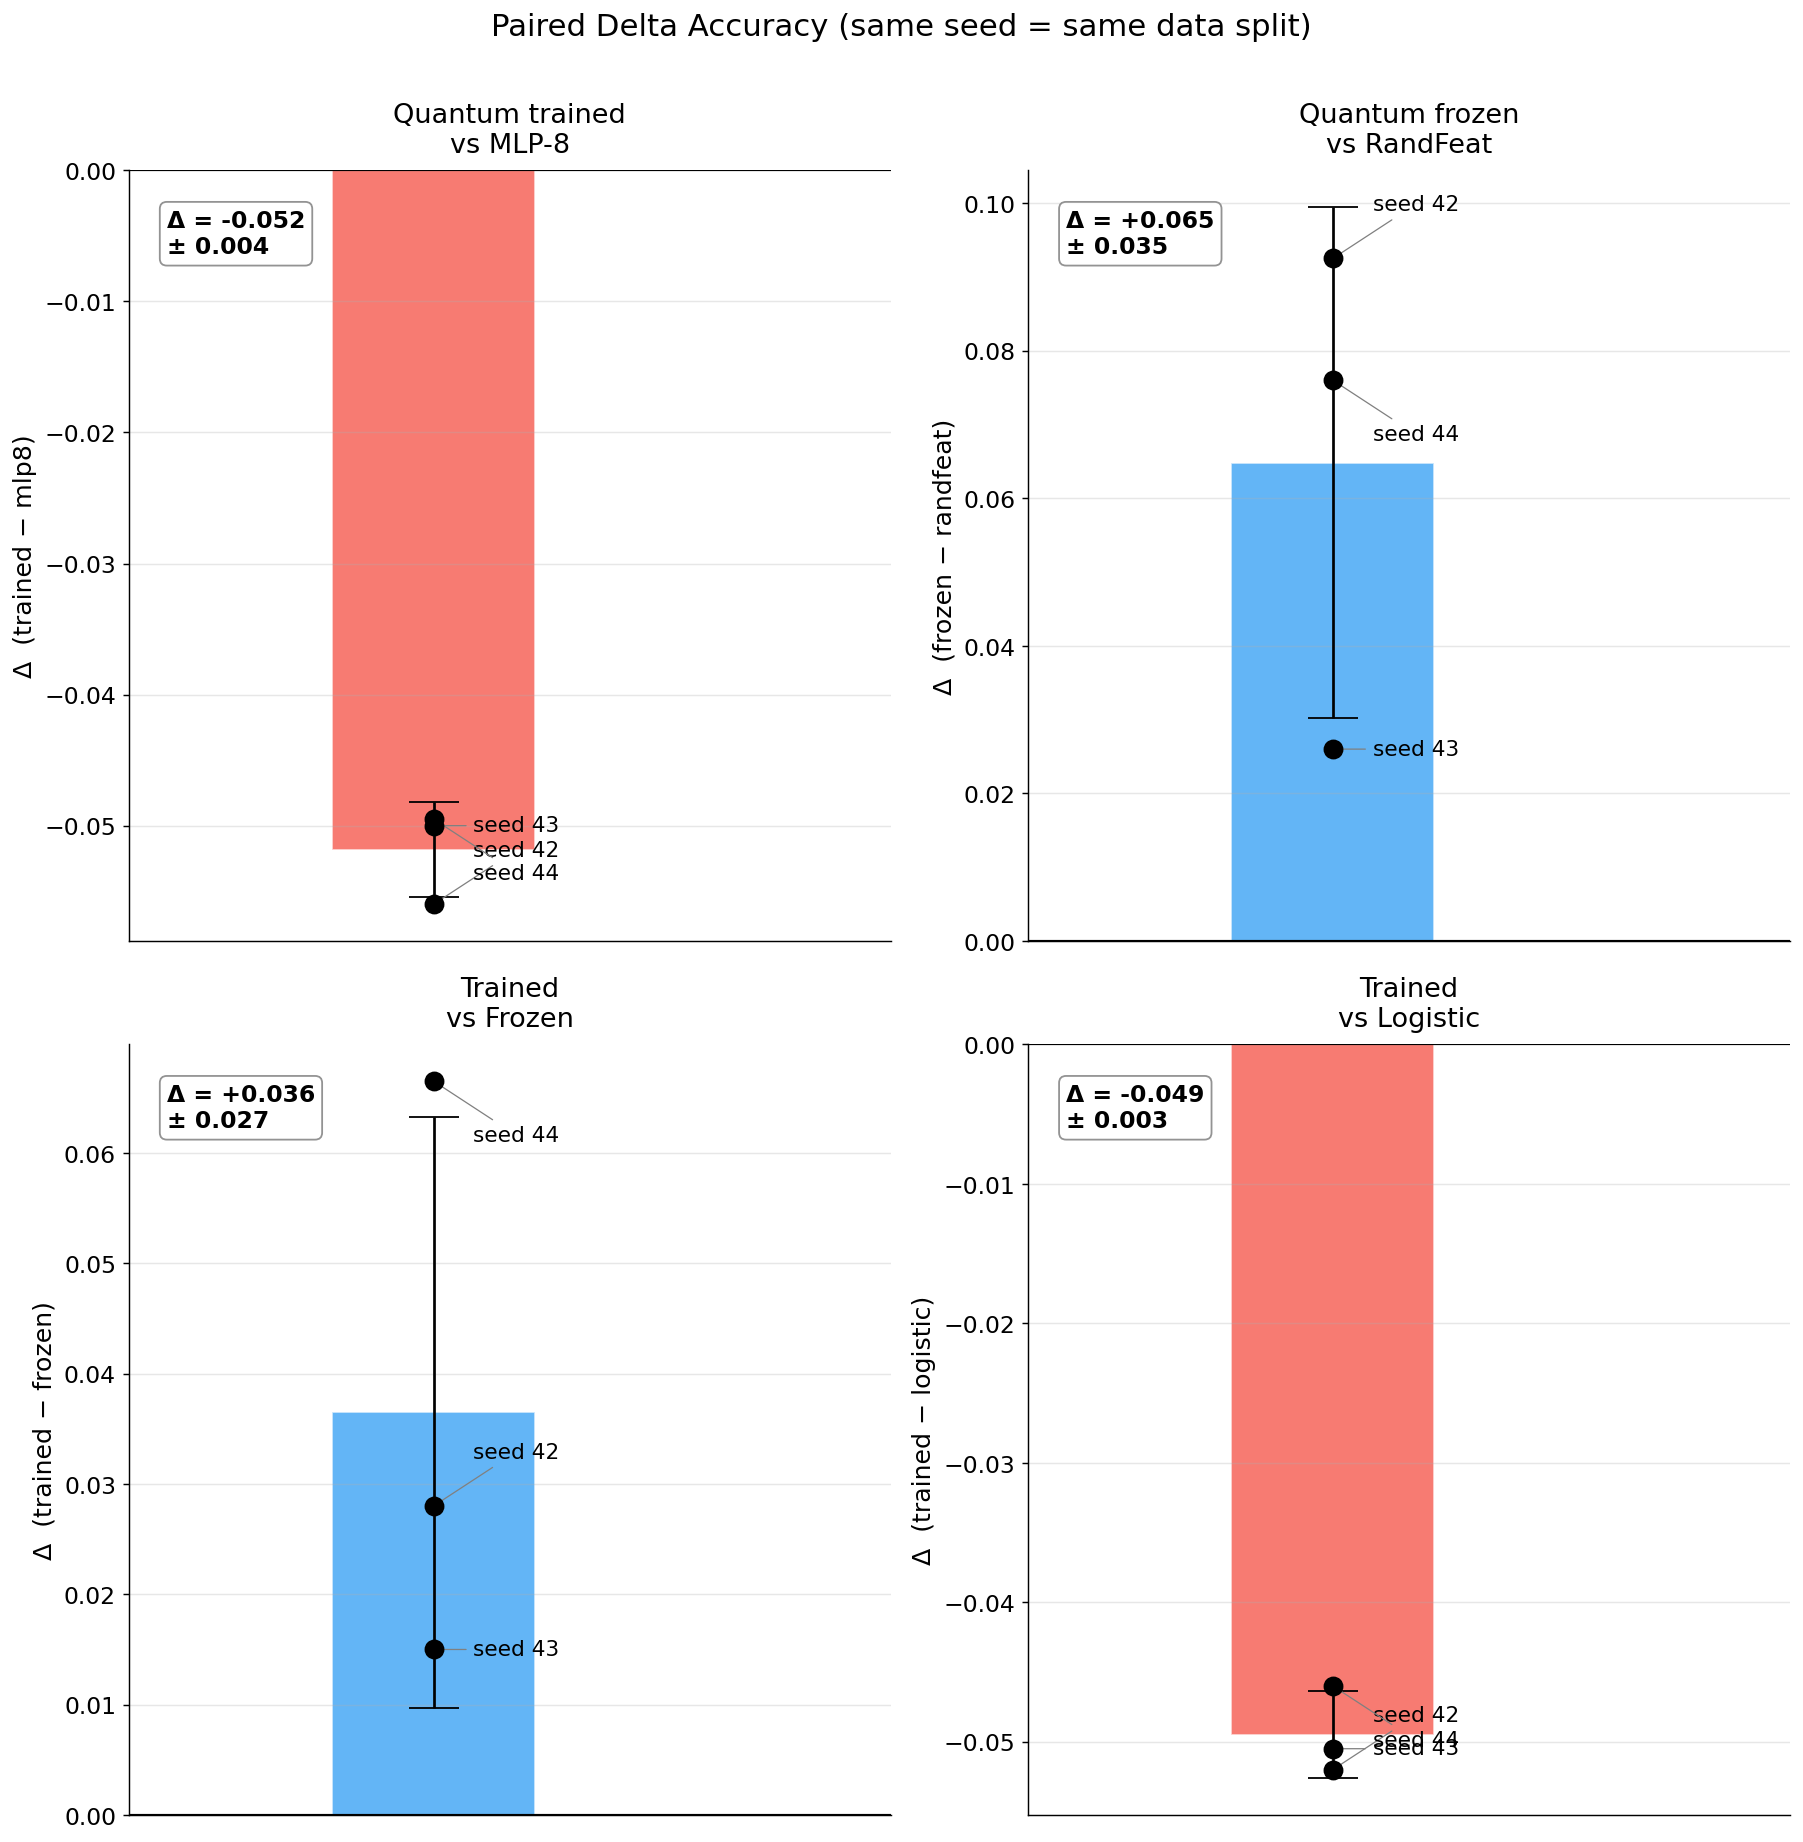


Paired delta summary:
  Comparison                mean Delta std Delta  per-seed
  trained - mlp8             -0.0518  0.0036  ['-0.0560', '-0.0500', '-0.0495']
  frozen - randfeat          +0.0648  0.0346  ['+0.0925', '+0.0260', '+0.0760']
  trained - frozen           +0.0365  0.0268  ['+0.0280', '+0.0150', '+0.0665']
  trained - logistic         -0.0495  0.0031  ['-0.0520', '-0.0505', '-0.0460']


In [12]:
if df3 is None:
    _nd3("6.2")
else:
    pivot3 = df3.pivot_table(index="seed", columns="arm", values="test_acc")
    seeds  = pivot3.index.tolist()

    COMPS = [
        ("trained","mlp8",    "Quantum trained\nvs MLP-8"),
        ("frozen", "randfeat","Quantum frozen\nvs RandFeat"),
        ("trained","frozen",  "Trained\nvs Frozen"),
        ("trained","logistic","Trained\nvs Logistic"),
    ]
    valid = [(a,b,l) for a,b,l in COMPS if a in pivot3.columns and b in pivot3.columns]

    if not valid:
        print("WARNING:  Not enough arms for paired deltas. Need >=2 arms completed.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(14, 14), dpi=130)
        axf = axes.flatten()
        # 30-pt uniform vertical offset between the three seed annotations
        y_offsets = [30, 0, -30]
        for ax, (a1, a2, lbl) in zip(axf, valid):
            d = pivot3[a1] - pivot3[a2]
            mean_d, std_d = d.mean(), d.std()
            color = "#2196F3" if mean_d >= 0 else "#F44336"
            ax.bar([0], [mean_d], color=color, alpha=0.7, width=0.4,
                   yerr=std_d, capsize=14, edgecolor="white")
            for (s, v), yoff in zip(zip(seeds, d), y_offsets):
                ax.scatter(0, v, color="black", s=100, zorder=5)
                ax.annotate(f"seed {s}", (0, v), textcoords="offset points",
                            xytext=(22, yoff), fontsize=12, va="center",
                            arrowprops=dict(arrowstyle="-", color="gray", lw=0.7))
            ax.axhline(0, color="black", lw=1.2)
            ax.set_xlim(-0.6, 0.9)
            ax.set_xticks([])
            ax.set_ylabel(f"Δ  ({a1} − {a2})", fontsize=14)
            ax.set_title(lbl, fontsize=15, pad=10)
            ax.tick_params(axis="y", labelsize=13)
            ax.text(0.05, 0.95,
                    f'Δ = {mean_d:+.3f}\n± {std_d:.3f}',
                    transform=ax.transAxes,
                    va="top", ha="left", fontsize=13, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
        fig.suptitle("Paired Delta Accuracy (same seed = same data split)",
                     fontsize=17, y=1.01)
        plt.tight_layout()
        plt.show()

        print("\nPaired delta summary:")
        print(f"  {'Comparison':<25} {'mean Delta':>8} {'std Delta':>7}  per-seed")
        for a1, a2, _ in valid:
            if a1 in pivot3.columns and a2 in pivot3.columns:
                d = pivot3[a1] - pivot3[a2]
                print(f"  {a1+' - '+a2:<25} {d.mean():>+8.4f} {d.std():>7.4f}  "
                      f"{[f'{v:+.4f}' for v in d.values]}")

### 6.3 Training Dynamics

Train accuracy (solid line) and validation accuracy (dashed line) for each arm,
mean ± std over seeds. A persistent gap between the two curves indicates overfitting.

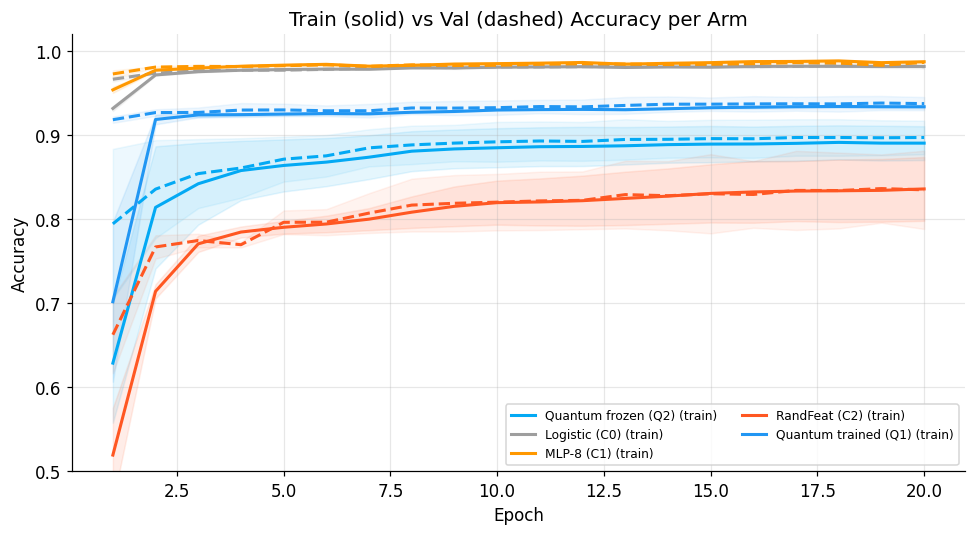

In [13]:
if not curves3:
    _nd3("6.3 - no metrics.csv found")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    for arm, seed_dfs in sorted(curves3.items()):
        max_ep = max(c["epoch"].max() for c in seed_dfs)
        tr_mat = np.full((len(seed_dfs), int(max_ep)), np.nan)
        va_mat = np.full((len(seed_dfs), int(max_ep)), np.nan)
        for si, c in enumerate(seed_dfs):
            ep = c["epoch"].astype(int).values - 1
            for e, ta, va in zip(ep, c["train_acc"].values, c["val_acc"].values):
                if 0 <= e < int(max_ep):
                    tr_mat[si,e]=ta; va_mat[si,e]=va
        x = np.arange(1, int(max_ep)+1)
        color = ARM_COLORS.get(arm,"#9E9E9E")
        label = ARM_LABELS.get(arm,arm)
        m_tr = np.nanmean(tr_mat, 0); s_tr = np.nanstd(tr_mat, 0)
        m_va = np.nanmean(va_mat, 0); s_va = np.nanstd(va_mat, 0)
        ax.plot(x, m_tr, color=color, lw=2, label=f"{label} (train)")
        ax.fill_between(x, m_tr-s_tr, m_tr+s_tr, alpha=0.10, color=color)
        ax.plot(x, m_va, color=color, lw=2, ls="--")
        ax.fill_between(x, m_va-s_va, m_va+s_va, alpha=0.07, color=color)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_ylim(0.5, 1.02)
    ax.set_title("Train (solid) vs Val (dashed) Accuracy per Arm", fontsize=13)
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    plt.tight_layout(); plt.show()

### 6.4 Confusion Matrices

One matrix per arm, summed over the three seeds. Cell values show absolute counts;
cell colour encodes the row-normalised fraction (recall per class).

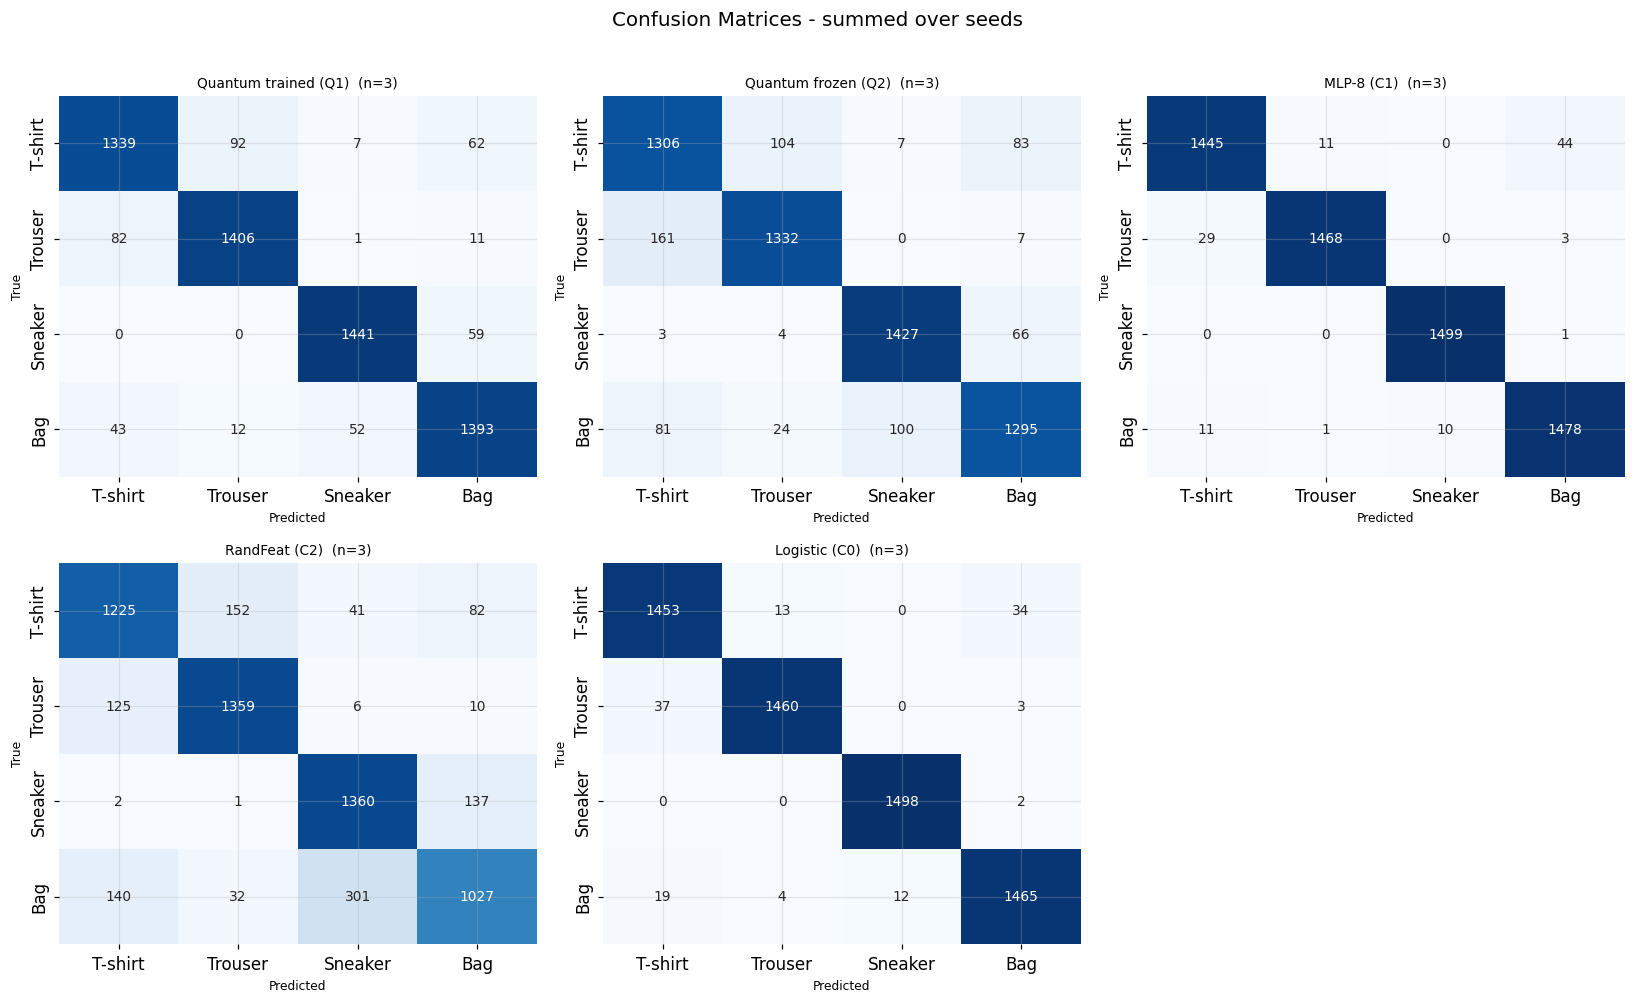

In [14]:
def _extract_cm(row, n=4):
    cm = np.zeros((n,n), dtype=int)
    for i in range(n):
        for j in range(n):
            col=f"cm_{i}{j}"
            if col in row.index and not pd.isna(row[col]):
                cm[i,j]=int(row[col])
    return cm

if df3 is None:
    _nd3("6.4")
else:
    present = [a for a in ARMS if a in df3["arm"].unique()]
    ncols = min(3, len(present)); nrows = (len(present)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4.5*nrows), squeeze=False)
    axf = axes.flatten()
    for idx, arm in enumerate(present):
        sub = df3[df3["arm"]==arm]
        cm = sum(_extract_cm(r) for _,r in sub.iterrows())
        norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        sns.heatmap(norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    ax=axf[idx], cbar=False, annot_kws={"size":9})
        axf[idx].set_title(f"{ARM_LABELS.get(arm,arm)}  (n={len(sub)})", fontsize=9)
        axf[idx].set_xlabel("Predicted", fontsize=8); axf[idx].set_ylabel("True", fontsize=8)
    for ax in axf[len(present):]: ax.set_visible(False)
    fig.suptitle("Confusion Matrices - summed over seeds", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()